In [34]:
# Importing dependencies 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score,
                             ConfusionMatrixDisplay,RocCurveDisplay)
import shap
import warnings
warnings.filterwarnings("ignore")



# Loading the dataset

In [35]:
df = pd.read_csv("D:/Python programming/Projects/Credit-Card-Default-Prediction/dataset/amex_credit_card.csv")

In [36]:
df.shape

(45528, 19)

In [37]:
df.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45528 entries, 0 to 45527
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              45528 non-null  str    
 1   name                     45528 non-null  str    
 2   age                      45528 non-null  int64  
 3   gender                   45528 non-null  str    
 4   owns_car                 44981 non-null  str    
 5   owns_house               45528 non-null  str    
 6   no_of_children           44754 non-null  float64
 7   net_yearly_income        45528 non-null  float64
 8   no_of_days_employed      45065 non-null  float64
 9   occupation_type          45528 non-null  str    
 10  total_family_members     45445 non-null  float64
 11  migrant_worker           45441 non-null  float64
 12  yearly_debt_payments     45433 non-null  float64
 13  credit_limit             45528 non-null  float64
 14  credit_limit_used(%)     45528 no

# Data preprocessing

In [39]:
df["migrant_worker"] = df["migrant_worker"].map({1: "Yes",0: "No"})

In [40]:
df = df[df["gender"]!="XNA"] # Removing unknown gender entry

In [41]:
# Dropping rows with missing values from columns with very few missing values
df.dropna(subset=["yearly_debt_payments","migrant_worker","total_family_members","credit_score"],inplace=True)

In [42]:
df.loc[df["no_of_days_employed"]>((df["age"]-15)*365),"no_of_days_employed"] = 0
df["no_of_days_employed"] = df["no_of_days_employed"].fillna(0) # cleaning no_of_days_employed column

In [43]:
df["is_employed"] = (df["no_of_days_employed"] != 0).astype(int) # creating another feature
df["years_experienced"] = df["no_of_days_employed"]/365
df["years_experienced"] = df["years_experienced"].round(2)

In [44]:
df.drop(columns=["customer_id", "name"], inplace=True)

In [45]:
skewed_col = ["net_yearly_income","yearly_debt_payments","credit_limit"]
df[["log_net_yearly_income","log_yearly_debt_payments","log_credit_limit"]]=np.log1p(df[skewed_col]) # Applying transformation on highly skewed features

In [46]:
# Convert all categorical columns from object/string to category dtype
categorical_cols = ["gender","owns_car","owns_house","occupation_type","migrant_worker","is_employed"]
df[categorical_cols] = df[categorical_cols].astype("category")

In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 45255 entries, 0 to 45527
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       45255 non-null  int64   
 1   gender                    45255 non-null  category
 2   owns_car                  44712 non-null  category
 3   owns_house                45255 non-null  category
 4   no_of_children            44484 non-null  float64 
 5   net_yearly_income         45255 non-null  float64 
 6   no_of_days_employed       45255 non-null  float64 
 7   occupation_type           45255 non-null  category
 8   total_family_members      45255 non-null  float64 
 9   migrant_worker            45255 non-null  category
 10  yearly_debt_payments      45255 non-null  float64 
 11  credit_limit              45255 non-null  float64 
 12  credit_limit_used(%)      45255 non-null  int64   
 13  credit_score              45255 non-null  float64 
 14  prev_d

In [48]:
df.isnull().sum()

age                           0
gender                        0
owns_car                    543
owns_house                    0
no_of_children              771
net_yearly_income             0
no_of_days_employed           0
occupation_type               0
total_family_members          0
migrant_worker                0
yearly_debt_payments          0
credit_limit                  0
credit_limit_used(%)          0
credit_score                  0
prev_defaults                 0
default_in_last_6months       0
credit_card_default           0
is_employed                   0
years_experienced             0
log_net_yearly_income         0
log_yearly_debt_payments      0
log_credit_limit              0
dtype: int64

In [49]:
target = "credit_card_default"
features = ['age', 'gender', 'owns_car', 'owns_house', 'no_of_children','occupation_type','total_family_members', 'migrant_worker',
            'credit_limit_used(%)', 'credit_score', 'prev_defaults','default_in_last_6months','is_employed','years_experienced',
            'log_net_yearly_income','log_yearly_debt_payments', 'log_credit_limit'] # final feature on which we will train our model

In [50]:
x = df[features]
y = df[target]

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,stratify=y)

## Building pipeline

#### Missing value imputation

In [52]:
mode_imputer = SimpleImputer(strategy="most_frequent")
x_train["owns_car"] = mode_imputer.fit_transform(x_train[["owns_car"]]).ravel()
x_test["owns_car"] = mode_imputer.transform(x_test[["owns_car"]]).ravel()

knn_imputer = KNNImputer(n_neighbors=5)
x_train["no_of_children"] = knn_imputer.fit_transform(x_train[["no_of_children"]]).ravel()
x_test["no_of_children"] = knn_imputer.transform(x_test[["no_of_children"]]).ravel()

x_train["owns_car"] = x_train["owns_car"].astype("category")
x_test["owns_car"] = x_test["owns_car"].astype("category")

x_train["no_of_children"] = x_train["no_of_children"].astype(int)
x_test["no_of_children"] = x_test["no_of_children"].astype(int)

In [53]:
x_test.isnull().sum()

age                         0
gender                      0
owns_car                    0
owns_house                  0
no_of_children              0
occupation_type             0
total_family_members        0
migrant_worker              0
credit_limit_used(%)        0
credit_score                0
prev_defaults               0
default_in_last_6months     0
is_employed                 0
years_experienced           0
log_net_yearly_income       0
log_yearly_debt_payments    0
log_credit_limit            0
dtype: int64

#### SMOTENC

In [54]:
categorical_cols = ["gender","owns_car","owns_house","occupation_type","migrant_worker","is_employed"]
categorical_indices = [x_train.columns.get_loc(col)for col in categorical_cols]
print(categorical_indices)

[1, 2, 3, 5, 7, 12]


In [55]:
smotenc = SMOTENC(categorical_features=categorical_indices,random_state=42)
x_train, y_train = smotenc.fit_resample(x_train,y_train)

### Encoding

In [56]:
ohe_cols = ["gender","owns_car","owns_house", "migrant_worker","is_employed"]
te_cols = ["occupation_type"]
scaling_cols = ["age","total_family_members","credit_limit_used(%)","credit_score","prev_defaults","default_in_last_6months","years_experienced",
    "log_net_yearly_income","log_yearly_debt_payments","log_credit_limit"]

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
ohe_encoder = OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
target_encoder = TargetEncoder(cv=cv,target_type="binary")
transformer = ColumnTransformer( transformers=[("target_encoding", target_encoder, te_cols),
                                                ("onehot_encoding", ohe_encoder, ohe_cols),
                                                ("scaling", StandardScaler(), scaling_cols)],
                                remainder="passthrough",verbose_feature_names_out=False).set_output(transform="pandas")

### Logistic Regression

In [57]:
baseline_pipeline = Pipeline(steps=[("transfromer", transformer),
                                    ("basline_lr", LogisticRegression(random_state=42, max_iter=1000))])

In [58]:
baseline_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transfromer', ...), ('basline_lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['age','gender','owns_car',...,'log_net_yearly_income', 'log_yearly_debt_payments','log_credit_limit']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('target_encoding', ...), ('onehot_encoding', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defaul

In [59]:
# prediction
y_pred = baseline_pipeline.predict(x_test)
y_prob = baseline_pipeline.predict_proba(x_test)[:,1]

In [60]:
def model_evaluation(model, x_train, y_train, x_test, y_test):

    # ============================
    # Training Predictions
    # ============================
    train_pred = model.predict(x_train)
    train_prob = model.predict_proba(x_train)[:, 1]

    # ============================
    # Testing Predictions
    # ============================
    test_pred = model.predict(x_test)
    test_prob = model.predict_proba(x_test)[:, 1]

    # ============================
    # Training Metrics
    # ============================
    train_accuracy = accuracy_score(y_train, train_pred)
    train_precision = precision_score(y_train, train_pred)
    train_recall = recall_score(y_train, train_pred)
    train_f1 = f1_score(y_train, train_pred)
    train_roc_auc = roc_auc_score(y_train, train_prob)

    # ============================
    # Testing Metrics
    # ============================
    test_accuracy = accuracy_score(y_test, test_pred)
    test_precision = precision_score(y_test, test_pred)
    test_recall = recall_score(y_test, test_pred)
    test_f1 = f1_score(y_test, test_pred)
    test_roc_auc = roc_auc_score(y_test, test_prob)

    # ============================
    # Print Metrics
    # ============================
    print("=" * 50)
    print("Training Metrics")
    print("=" * 50)

    print(f"Accuracy Score : {train_accuracy:.4f}")
    print(f"Precision      : {train_precision:.4f}")
    print(f"Recall         : {train_recall:.4f}")
    print(f"F1 Score       : {train_f1:.4f}")
    print(f"ROC-AUC Score  : {train_roc_auc:.4f}")

    print("\n" + "=" * 50)
    print("Testing Metrics")
    print("=" * 50)

    print(f"Accuracy Score : {test_accuracy:.4f}")
    print(f"Precision      : {test_precision:.4f}")
    print(f"Recall         : {test_recall:.4f}")
    print(f"F1 Score       : {test_f1:.4f}")
    print(f"ROC-AUC Score  : {test_roc_auc:.4f}")
    # ============================
    # Confusion Matrix
    # ============================
    print("\nConfusion Matrix\n")

    ConfusionMatrixDisplay.from_predictions(y_test,test_pred,cmap="Blues")

    plt.show()

    # ============================
    # Classification Report
    # ============================
    print("\nClassification Report\n")
    print(classification_report(y_test, test_pred))

Training Metrics
Accuracy Score : 0.9651
Precision      : 0.9601
Recall         : 0.9706
F1 Score       : 0.9653
ROC-AUC Score  : 0.9958

Testing Metrics
Accuracy Score : 0.9548
Precision      : 0.6589
Recall         : 0.9197
F1 Score       : 0.7677
ROC-AUC Score  : 0.9914

Confusion Matrix



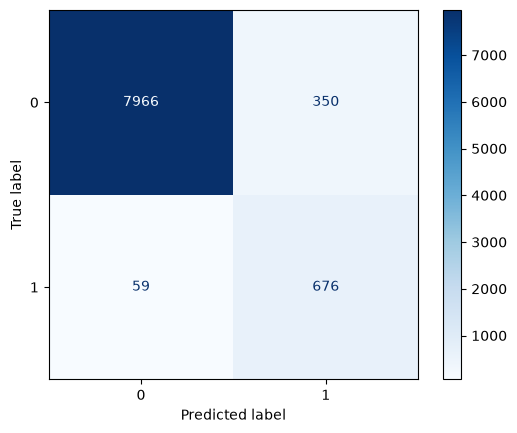


Classification Report

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      8316
           1       0.66      0.92      0.77       735

    accuracy                           0.95      9051
   macro avg       0.83      0.94      0.87      9051
weighted avg       0.97      0.95      0.96      9051



In [61]:
model_evaluation(baseline_pipeline,x_train,y_train,x_test,y_test)

<Figure size 600x500 with 0 Axes>

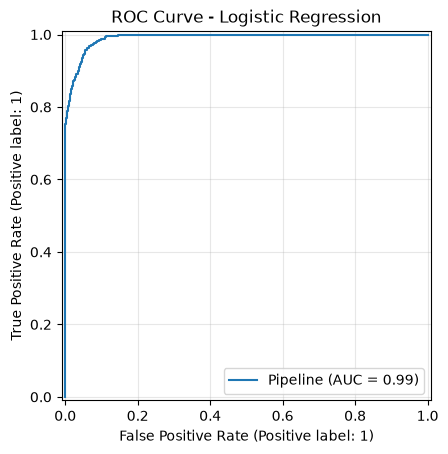

In [62]:
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_estimator(baseline_pipeline,x_test,y_test)
plt.title("ROC Curve - Logistic Regression")
plt.grid(alpha=0.3)
plt.show()

In [63]:
param_grid = {
    "basline_lr__C": [0.01, 0.1, 1, 10, 100],
    "basline_lr__penalty": ["elasticnet"],
    "basline_lr__l1_ratio": [0, 0.25, 0.5, 0.75, 1],
    "basline_lr__solver": ["saga"],
    "basline_lr__class_weight": [None, "balanced"]
}
grid = GridSearchCV(estimator=baseline_pipeline, param_grid=param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=2)
grid.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'basline_lr__C': [0.01, 0.1, ...], 'basline_lr__class_weight': [None, 'balanced'], 'basline_lr__l1_ratio': [0, 0.25, ...], 'basline_lr__penalty': ['elasticnet'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multipl

In [64]:
print("Best Parameters:")
print(grid.best_params_)
print("\nBest Cross Validation ROC-AUC:")
print(grid.best_score_)
best_lr_model = grid.best_estimator_

Best Parameters:
{'basline_lr__C': 100, 'basline_lr__class_weight': None, 'basline_lr__l1_ratio': 0.25, 'basline_lr__penalty': 'elasticnet', 'basline_lr__solver': 'saga'}

Best Cross Validation ROC-AUC:
0.9956736759575533


Training Metrics
Accuracy Score : 0.9652
Precision      : 0.9602
Recall         : 0.9706
F1 Score       : 0.9654
ROC-AUC Score  : 0.9958

Testing Metrics
Accuracy Score : 0.9549
Precision      : 0.6595
Recall         : 0.9197
F1 Score       : 0.7682
ROC-AUC Score  : 0.9914

Confusion Matrix



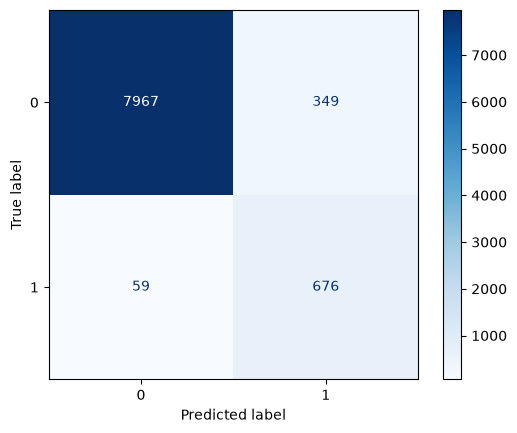


Classification Report

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      8316
           1       0.66      0.92      0.77       735

    accuracy                           0.95      9051
   macro avg       0.83      0.94      0.87      9051
weighted avg       0.97      0.95      0.96      9051



In [65]:
model_evaluation(best_lr_model,x_train,y_train,x_test,y_test)

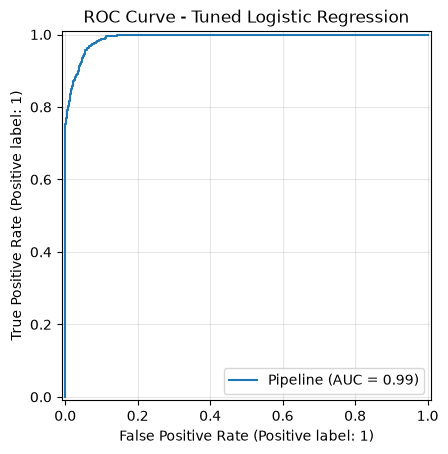

In [66]:
RocCurveDisplay.from_estimator(best_lr_model, x_test, y_test)
plt.title("ROC Curve - Tuned Logistic Regression")
plt.grid(alpha=0.3)
plt.show()

### Random Forest

In [67]:
rf_pipeline = Pipeline(steps=[("transformer", transformer),
                            ("random_forest", RandomForestClassifier(random_state=42))]
                            )

In [68]:
param_dist = {
    "random_forest__n_estimators": [300, 500, 700],

    "random_forest__max_depth": [10, 12, 15],

    "random_forest__min_samples_split": [15, 20, 25],

    "random_forest__min_samples_leaf": [5, 8, 10],

    "random_forest__max_features": ["sqrt"],

    "random_forest__bootstrap": [True],

    "random_forest__criterion": ["gini", "entropy"],

    "random_forest__max_leaf_nodes": [50, 100, 150, None]
}
rf_random_search = RandomizedSearchCV(estimator=rf_pipeline, param_distributions=param_dist, n_iter=40, scoring="roc_auc", cv=5, random_state=42, n_jobs=-1, verbose=2)
rf_random_search.fit(x_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random_forest__bootstrap': [True], 'random_forest__criterion': ['gini', 'entropy'], 'random_forest__max_depth': [10, 12, ...], 'random_forest__max_features': ['sqrt'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, 

In [69]:
best_rf_model = rf_random_search.best_estimator_

In [70]:
rf_random_search.best_params_

{'random_forest__n_estimators': 500,
 'random_forest__min_samples_split': 15,
 'random_forest__min_samples_leaf': 5,
 'random_forest__max_leaf_nodes': None,
 'random_forest__max_features': 'sqrt',
 'random_forest__max_depth': 15,
 'random_forest__criterion': 'entropy',
 'random_forest__bootstrap': True}

Training Metrics
Accuracy Score : 0.9875
Precision      : 0.9784
Recall         : 0.9971
F1 Score       : 0.9877
ROC-AUC Score  : 0.9996

Testing Metrics
Accuracy Score : 0.9661
Precision      : 0.7301
Recall         : 0.9238
F1 Score       : 0.8156
ROC-AUC Score  : 0.9944

Confusion Matrix



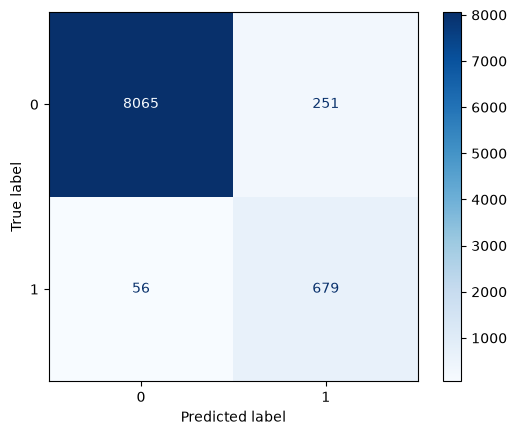


Classification Report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      8316
           1       0.73      0.92      0.82       735

    accuracy                           0.97      9051
   macro avg       0.86      0.95      0.90      9051
weighted avg       0.97      0.97      0.97      9051



In [71]:
model_evaluation(best_rf_model, x_train, y_train, x_test, y_test)

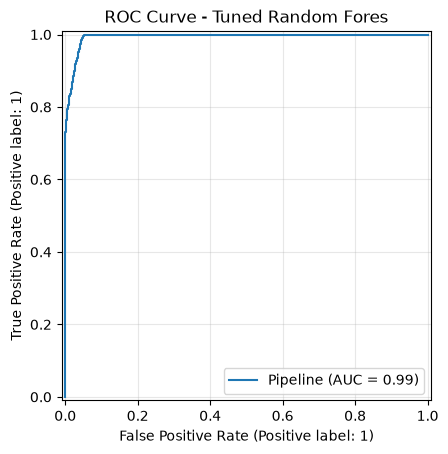

In [72]:
RocCurveDisplay.from_estimator(best_rf_model, x_test, y_test)
plt.title("ROC Curve - Tuned Random Fores")
plt.grid(alpha=0.3)
plt.show()

### XGBoost

In [73]:
xgb_pipeline = Pipeline(steps=[("transformer", transformer),
                               ("xgboost", XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=42))]
                               )

In [74]:
param_dist = {
    "xgboost__max_depth": [2, 3, 4, 6],
    "xgboost__learning_rate": [0.01, 0.03, 0.05],
    "xgboost__n_estimators": [300, 500, 700],
    "xgboost__min_child_weight": [5, 7, 10],
    "xgboost__subsample": [0.6, 0.7, 0.8],
    "xgboost__colsample_bytree": [0.6, 0.7, 0.8],
    "xgboost__gamma": [0.5, 1, 2],
    "xgboost__reg_alpha": [0.5, 1, 2],
    "xgboost__reg_lambda": [5, 10, 20]
}
xgb_random_search = RandomizedSearchCV(estimator=xgb_pipeline,param_distributions=param_dist,n_iter=30,scoring="roc_auc",cv=5,random_state=42,n_jobs=-1,verbose=2)
xgb_random_search.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgboost__colsample_bytree': [0.6, 0.7, ...], 'xgboost__gamma': [0.5, 1, ...], 'xgboost__learning_rate': [0.01, 0.03, ...], 'xgboost__max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`

In [75]:
print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest ROC-AUC Score:")
print(xgb_random_search.best_score_)

Best Parameters:
{'xgboost__subsample': 0.8, 'xgboost__reg_lambda': 10, 'xgboost__reg_alpha': 0.5, 'xgboost__n_estimators': 300, 'xgboost__min_child_weight': 7, 'xgboost__max_depth': 6, 'xgboost__learning_rate': 0.05, 'xgboost__gamma': 1, 'xgboost__colsample_bytree': 0.7}

Best ROC-AUC Score:
0.9991744622248323


Training Metrics
Accuracy Score : 0.9877
Precision      : 0.9822
Recall         : 0.9935
F1 Score       : 0.9878
ROC-AUC Score  : 0.9995

Testing Metrics
Accuracy Score : 0.9691
Precision      : 0.7680
Recall         : 0.8871
F1 Score       : 0.8232
ROC-AUC Score  : 0.9945

Confusion Matrix



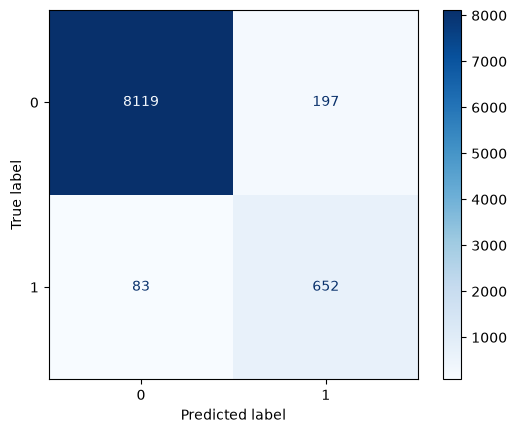


Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      8316
           1       0.77      0.89      0.82       735

    accuracy                           0.97      9051
   macro avg       0.88      0.93      0.90      9051
weighted avg       0.97      0.97      0.97      9051



In [76]:
best_xgb = xgb_random_search.best_estimator_
model_evaluation(best_xgb,x_train,y_train,x_test,y_test)

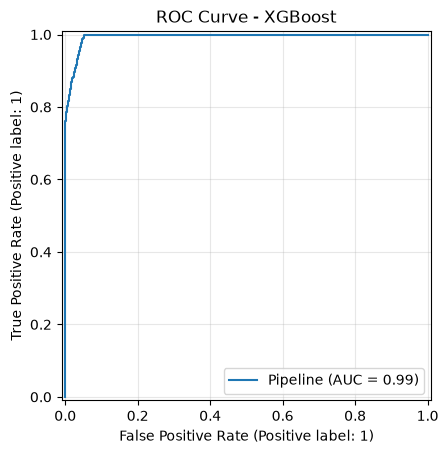

In [77]:
RocCurveDisplay.from_estimator(best_xgb, x_test, y_test)
plt.title("ROC Curve - XGBoost")
plt.grid(alpha=0.3)
plt.show()

### Conclusion

Three models were evaluated: Logistic Regression, Random Forest, and XGBoost. Logistic Regression achieved the highest **Recall (0.9388)** but had the lowest **Precision (0.6546), F1-score (0.7714), and ROC-AUC (0.9920)**. XGBoost produced the highest **Accuracy (0.9686), Precision (0.7571), and F1-score (0.8238)** with only a slight drop in Recall (**0.9034**). Random Forest achieved the highest **ROC-AUC (0.9947)** and the best Recall among the tree-based models (**0.9401**), although its Precision and F1-score were lower than XGBoost. Therefore, **Random Forest** was selected as the final model because of its superior ranking ability (ROC-AUC) and high Recall, making it a strong candidate for further threshold tuning and SHAP-based interpretation.

### Threshold tuning for Random Forest : 

In [78]:
y_prob = best_rf_model.predict_proba(x_test)[:, 1]
best_threshold = 0.6
best_pred = (y_prob >= best_threshold).astype(int)

print(f"Threshold Used : {best_threshold:.2f}\n")

print(f"Accuracy  : {accuracy_score(y_test, best_pred):.4f}")
print(f"Precision : {precision_score(y_test, best_pred):.4f}")
print(f"Recall    : {recall_score(y_test, best_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, best_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

Threshold Used : 0.60

Accuracy  : 0.9696
Precision : 0.7771
Recall    : 0.8776
F1 Score  : 0.8243
ROC-AUC   : 0.9944


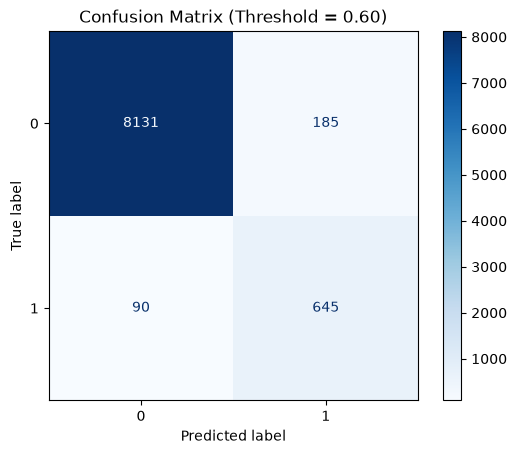

In [79]:
ConfusionMatrixDisplay.from_predictions(y_test,best_pred,cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.show()

We can set this threshold according to our objective

### Random Forest Model Interpretation using SHAP

In [80]:
rf_model = best_rf_model.named_steps["random_forest"] # extracting model from pipeline
x_test_transformed = best_rf_model.named_steps["transformer"].transform(x_test) # transforming test set
feature_names = best_rf_model.named_steps["transformer"].get_feature_names_out() # extracting feature names
x_test_shap = pd.DataFrame(x_test_transformed, columns= feature_names)

In [81]:
len(feature_names)

17

In [82]:
explainer = shap.Explainer(rf_model)
shap_values = explainer(x_test_shap)

In [83]:
shap_values.shape

(9051, 17, 2)

In [90]:
# Copy SHAP values for class 1
shap_values_display = shap_values[:, :, 1]

# Copy transformed dataframe
display_df = x_test_shap.copy()

# Replace scaled values with original values
for col in scaling_cols:
    display_df[col] = x_test[col].values

# Update SHAP display data
shap_values_display.data = display_df.values

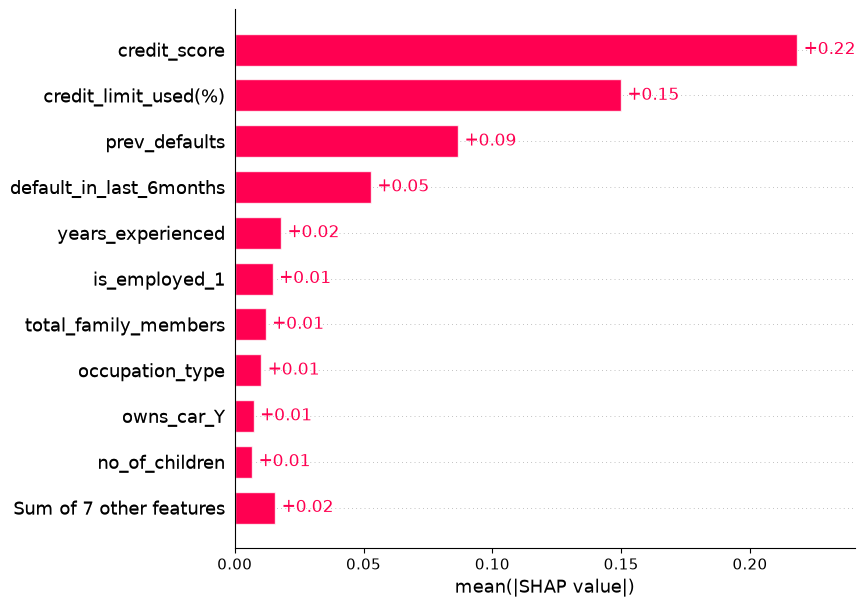

<Figure size 640x480 with 0 Axes>

In [91]:
plt.figure(figsize = (10,5))
shap.plots.bar(shap_values_display, max_display = 11)
plt.tight_layout()
plt.show()

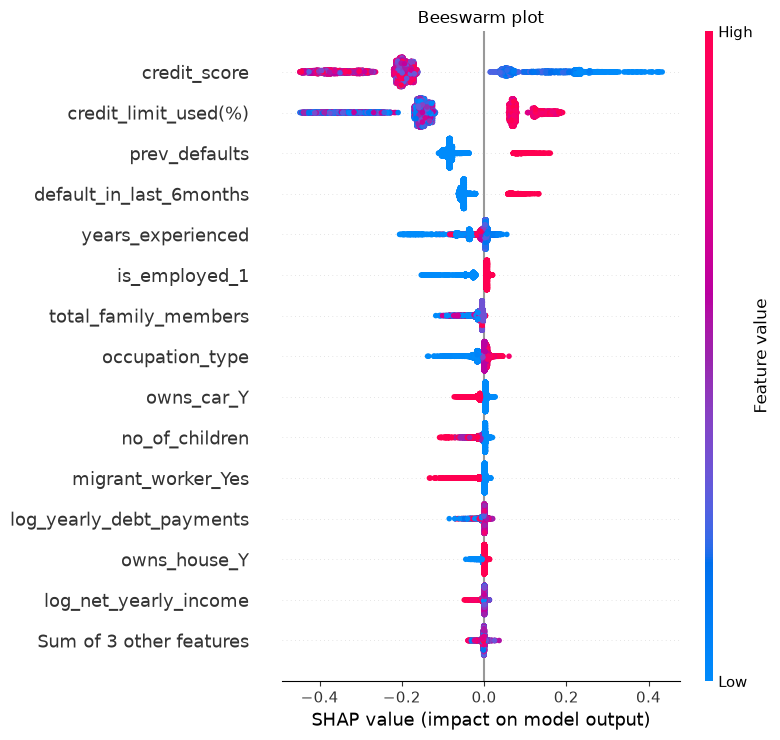

In [92]:
plt.figure(figsize=(6, 5))
shap.plots.beeswarm(shap_values_display,max_display=15,show=False)
plt.title("Beeswarm plot")
plt.tight_layout()
plt.show()

In [94]:
shap_values_display.shape

(9051, 17)

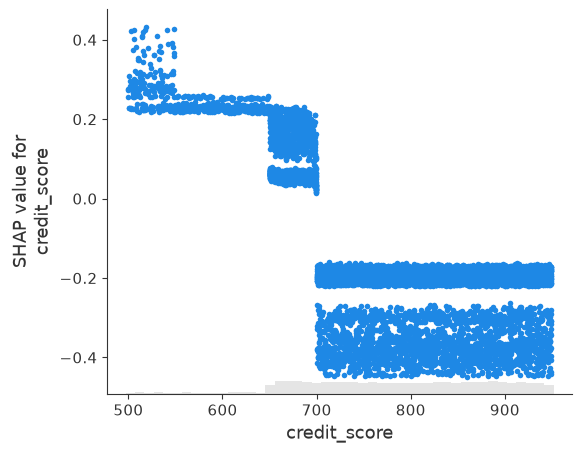

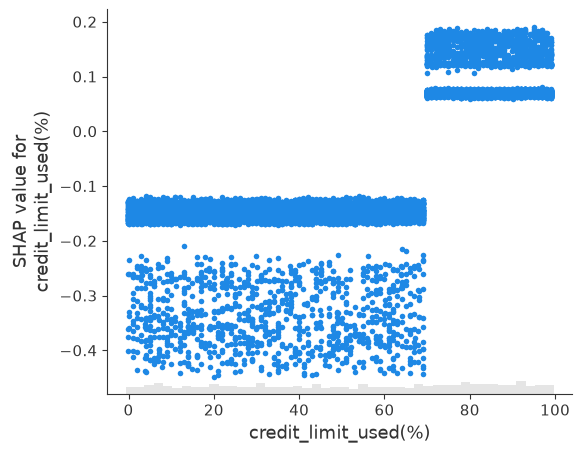

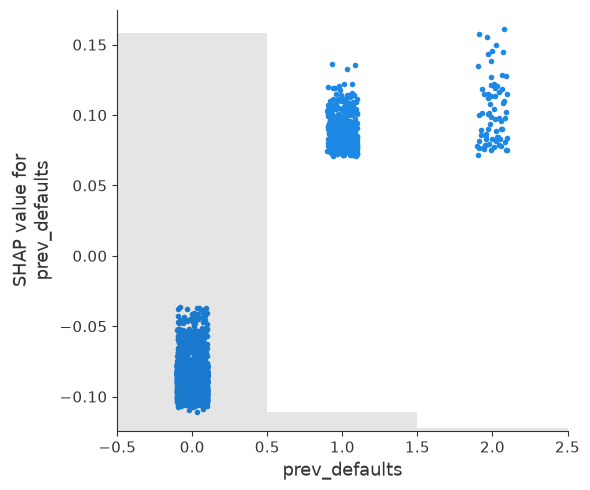

In [96]:
shap.plots.scatter(shap_values_display[:,"credit_score"],show=False)
shap.plots.scatter(shap_values_display[:,"credit_limit_used(%)"],show=False)
shap.plots.scatter(shap_values_display[:,"prev_defaults"],show=False)
plt.tight_layout()
plt.show()

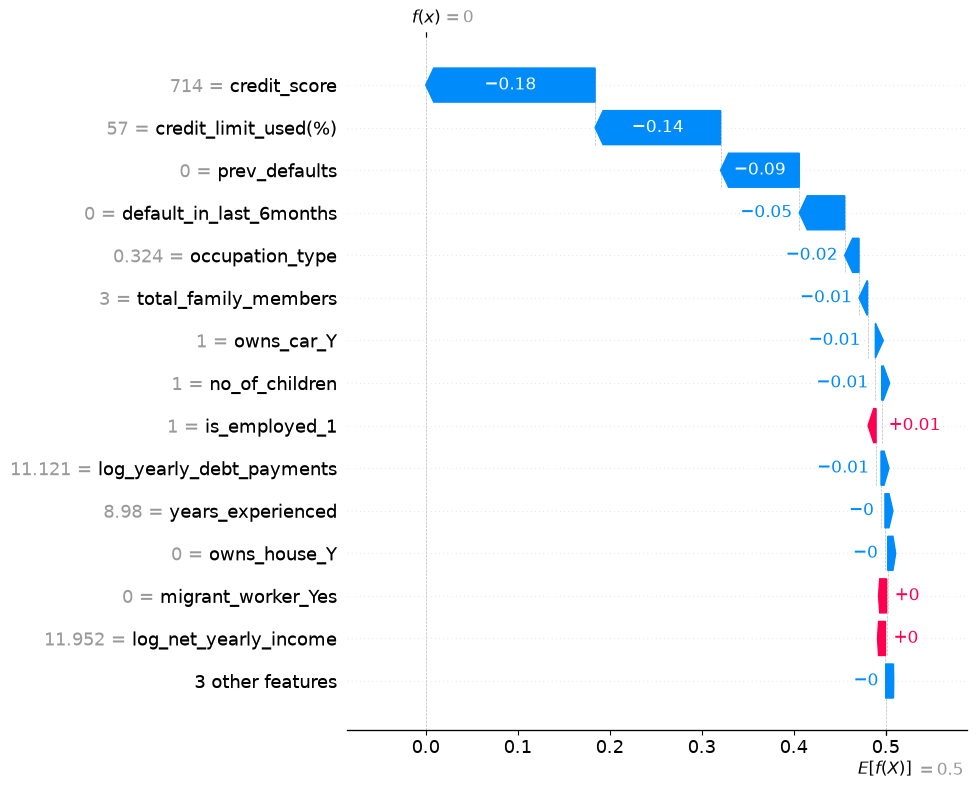

In [97]:
customer_index = 12
shap.plots.waterfall(shap_values_display[customer_index,:],max_display=15,show=False)
plt.show()